In [ ]:
import pandas as pd

url = "https://data.cityofnewyork.us/api/views/64uk-42ks/rows.csv?accessType=DOWNLOAD"
pluto = pd.read_csv(url, low_memory=False)


In [ ]:
"pluto" in globals()

True

In [ ]:
#We have 2 key columns in this dataset

[c for c in pluto.columns if "assess" in c.lower()]


['assessland', 'assesstot']

In [ ]:
#Rename columns

df = pluto.copy()

# rename for clarity
df = df.rename(columns={
    "assessland": "land_value",
    "assesstot": "total_value"
})

# building / improvement value
df["building_value"] = df["total_value"] - df["land_value"]

# land value ratio
df["land_value_ratio"] = df["land_value"] / df["total_value"]

df[["land_value", "building_value", "total_value", "land_value_ratio"]].head()


,land_value,building_value,total_value,land_value_ratio
0,88650.0,827100.0,915750.0,0.096806
1,1680750.0,47386350.0,49067100.0,0.034254
2,316800.0,4032900.0,4349700.0,0.072833
3,172800.0,2332350.0,2505150.0,0.068978
4,1191150.0,0.0,1191150.0,1.000000


In [ ]:
df = df[(df["land_value"] > 0) & (df["total_value"] > 0)].copy()


In [ ]:
#A look at our data

pluto.head()


,borough,Tax block,Tax lot,community board,census tract 2010,cb2010,schooldist,council district,postcode,firecomp,...,bctcb2020,geom,basempdate,dcasdate,edesigdate,landmkdate,masdate,polidate,rpaddate,zoningdate
0,BX,2869,47,205.0,243.0,3000.0,10.0,14.0,10453.0,E075,...,2.024300e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MN,675,39,104.0,99.0,1017.0,2.0,3.0,10001.0,E034,...,1.009902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MN,698,54,104.0,99.0,1030.0,2.0,3.0,10001.0,E003,...,1.009902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MN,698,56,104.0,99.0,1030.0,2.0,3.0,10001.0,E003,...,1.009902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MN,698,28,104.0,99.0,1030.0,2.0,3.0,10001.0,E003,...,1.009902e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#A look at our columns

pluto.columns


Index(['borough', 'Tax block', 'Tax lot', 'community board',
       'census tract 2010', 'cb2010', 'schooldist', 'council district',
       'postcode', 'firecomp',
       ...
       'bctcb2020', 'geom', 'basempdate', 'dcasdate', 'edesigdate',
       'landmkdate', 'masdate', 'polidate', 'rpaddate', 'zoningdate'],
      dtype='object', length=101)

In [ ]:
pluto[["assessland", "assesstot","bldgarea","lotarea"]].head()


,assessland,assesstot,bldgarea,lotarea
0,88650.0,915750.0,36708.0,19146.0
1,1680750.0,49067100.0,313013.0,17281.0
2,316800.0,4349700.0,22524.0,3839.0
3,172800.0,2505150.0,11583.0,1918.0
4,1191150.0,1191150.0,0.0,12225.0


In [ ]:
#We change "assessland" to "land_value" and "assesstot" to "total_value" for readability

current_rate = 0.03
df["current_tax"] = df["total_value"] * current_rate
current_revenue = df["current_tax"].sum()


In [ ]:
#This gets us our LVT rate which is the tax that would be applied to land without accounting for building value, giving us a revenue-neutral rate.

LVT_rate = current_revenue / df["land_value"].sum()

In [ ]:
#This gets us our tax bill if we applied the new rate, and the tax change from the current tax to the LVT tax.

df["lvt_tax"] = df["land_value"] * LVT_rate
df["tax_change"] = df["lvt_tax"] - df["current_tax"]

In [ ]:
#This gives the total revenue for the current tax and the LVT tax which are almost identical.

current_revenue = df["current_tax"].sum()
lvt_revenue     = df["lvt_tax"].sum()

current_revenue, lvt_revenue


(np.float64(15273534332.819998), np.float64(15273534332.819998))

In [ ]:
#This says that 54% of parcels will see an increase in taxes and 45% of parcels will see a decrease in taxes.
#Despite this, the tax increases will likely be very small and the tax decreases will likely be very large because the overall tax change is 0.

(df["tax_change"] > 0).mean(), (df["tax_change"] < 0).mean()


(np.float64(0.543342583810494), np.float64(0.456657416189506))

In [ ]:
df["tax_change"].describe()


,tax_change
count,8.540100e+05
mean,-3.688169e-12
std,4.736450e+05
min,-1.932758e+07
25%,-4.580498e+02
50%,7.902765e+01
75%,5.738736e+02
max,2.929185e+08


In [ ]:
df["lvr"] = df["land_value"] / df["total_value"]

df.groupby(pd.cut(df["lvr"], bins=[0,0.1,0.2,0.3,0.5,1]))["tax_change"].mean()


/tmp/ipython-input-2269119683.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["lvr"], bins=[0,0.1,0.2,0.3,0.5,1]))["tax_change"].mean()


,tax_change
lvr,
"(0.0, 0.1]",-53636.727030
"(0.1, 0.2]",-6114.254105
"(0.2, 0.3]",928.831239
"(0.3, 0.5]",9271.004378
"(0.5, 1.0]",61083.690497


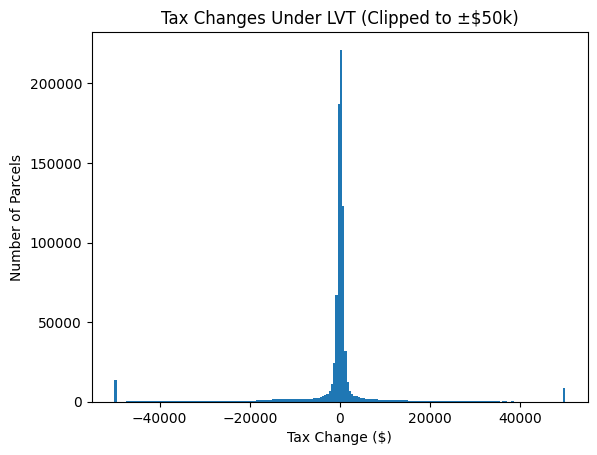

In [ ]:
import matplotlib.pyplot as plt

clipped = df["tax_change"].clip(-50000, 50000)  # cap at +/-50k
plt.hist(clipped, bins=200)
plt.title("Tax Changes Under LVT (Clipped to ±$50k)")
plt.xlabel("Tax Change ($)")
plt.ylabel("Number of Parcels")
plt.show()


In [ ]:
df.nlargest(10, "tax_change")[["land_value","total_value","lvr","tax_change"]]


,land_value,total_value,lvr,tax_change
125639,2.855118e+09,3.296988e+09,0.865977,2.929185e+08
120709,3.205634e+09,8.248909e+09,0.388613,1.924647e+08
527496,1.631545e+09,1.631545e+09,1.000000,1.749622e+08
728702,1.047865e+09,1.355975e+09,0.772776,1.031267e+08
116138,9.746860e+08,1.293628e+09,0.753452,9.495428e+07
129560,4.651731e+08,4.651731e+08,1.000000,4.988383e+07
125667,2.697676e+08,3.424280e+08,0.787808,2.674929e+07
138675,2.238026e+08,2.238026e+08,1.000000,2.399994e+07
727701,1.656648e+08,1.979770e+08,0.836788,1.679605e+07
124391,1.642679e+08,2.319278e+08,0.708272,1.558582e+07


In [ ]:
df.nsmallest(10, "tax_change")[["land_value","total_value","lvr","tax_change"]]

,land_value,total_value,lvr,tax_change
379012,225000000.0,1.673531e+09,0.134446,-1.932758e+07
509146,21774600.0,6.992860e+08,0.031138,-1.799030e+07
567948,58004101.0,7.436656e+08,0.077998,-1.434965e+07
841788,16198200.0,5.200000e+08,0.031150,-1.337701e+07
690152,17477100.0,5.237046e+08,0.033372,-1.331263e+07
838731,21836700.0,5.414630e+08,0.040329,-1.324708e+07
412778,5849550.0,4.603068e+08,0.012708,-1.300643e+07
567906,18495000.0,4.221590e+08,0.043811,-1.012657e+07
838732,12143250.0,3.916908e+08,0.031002,-1.008422e+07
631005,10741050.0,3.848810e+08,0.027907,-1.007236e+07


In [ ]:
df["FAR"] = df["bldgarea"] / df["lotarea"]


In [ ]:
df.groupby(pd.cut(df["FAR"], bins=[0,1,2,3,5,10]))["tax_change"].mean()


/tmp/ipython-input-3705790275.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["FAR"], bins=[0,1,2,3,5,10]))["tax_change"].mean()


,tax_change
FAR,
"(0, 1]",3112.445305
"(1, 2]",-1167.082721
"(2, 3]",-6315.125321
"(3, 5]",-18968.270177
"(5, 10]",-96462.970830


In [ ]:
vacant = df[df["bldgarea"] < 1000]  # essentially no building

In [ ]:
df["bldg_to_land_ratio"] = df["bldgarea"] / df["lotarea"]


In [ ]:
df.groupby(pd.cut(df["bldg_to_land_ratio"], bins=[0,0.1,0.5,1,5,10]))["tax_change"].mean()


/tmp/ipython-input-3738281511.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["bldg_to_land_ratio"], bins=[0,0.1,0.5,1,5,10]))["tax_change"].mean()


,tax_change
bldg_to_land_ratio,
"(0.0, 0.1]",411396.647879
"(0.1, 0.5]",2064.519806
"(0.5, 1.0]",511.593553
"(1.0, 5.0]",-4366.095242
"(5.0, 10.0]",-96462.970830


In [ ]:
df["land_value_per_sqft"] = df["land_value"] / df["lotarea"]


In [ ]:
df_big_land_tiny_building = df[
    (df["land_value"] > df["land_value"].quantile(0.80)) &
    (df["bldgarea"] < 2000)
]


In [ ]:
df["lvr"] = df["land_value"] / df["total_value"]
df[df["lvr"] > 0.7].head()


,borough,Tax block,Tax lot,community board,census tract 2010,cb2010,schooldist,council district,postcode,firecomp,...,zoningdate,building_value,land_value_ratio,current_tax,lvt_tax,tax_change,lvr,FAR,bldg_to_land_ratio,land_value_per_sqft
4,MN,698,28,104.0,99.0,1030.0,2.0,3.0,10001.0,E003,...,NaN,0.0,1.000000,35734.5,1.634700e+05,1.277355e+05,1.000000,0.000000,0.000000,97.435583
45,MN,1726,31,110.0,208.0,2002.0,5.0,9.0,10027.0,L030,...,NaN,0.0,1.000000,5494.5,2.513498e+04,1.964048e+04,1.000000,0.000000,0.000000,96.496312
77,MN,1288,69,105.0,102.0,1007.0,2.0,4.0,10022.0,E023,...,NaN,0.0,1.000000,283351.5,1.296212e+06,1.012860e+06,1.000000,15.252217,15.252217,854.755656
92,MN,1270,30,105.0,104.0,1001.0,2.0,4.0,10019.0,E023,...,NaN,462600.0,0.708617,47628.0,1.543918e+05,1.067638e+05,0.708617,3.778884,3.778884,448.207171
107,MN,1267,50,105.0,104.0,1004.0,2.0,4.0,10019.0,E023,...,NaN,788850.0,0.773894,104665.5,3.705402e+05,2.658747e+05,0.773894,1.585414,1.585414,535.077289
